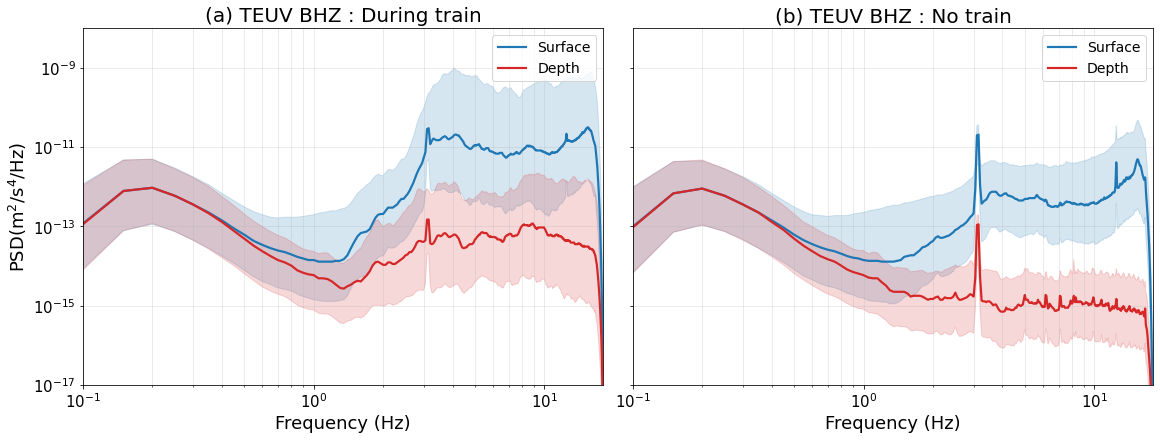

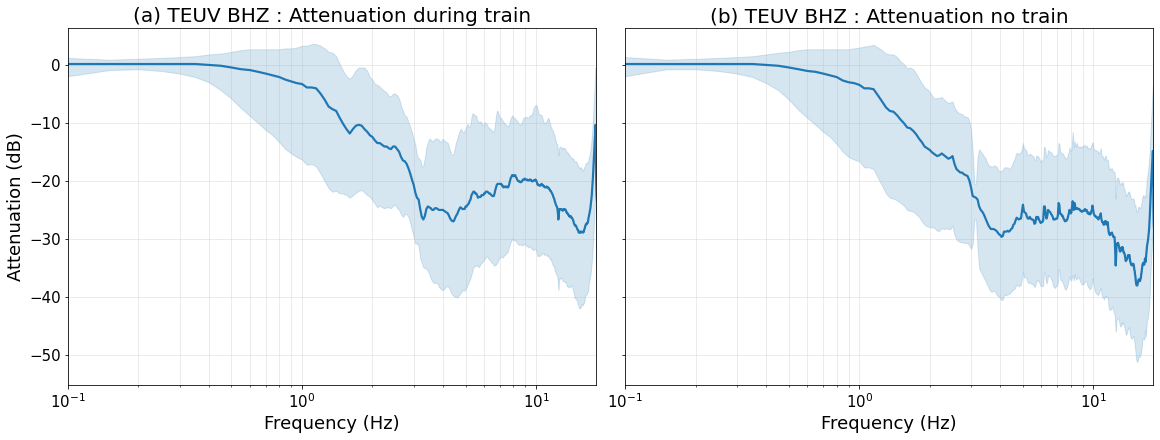

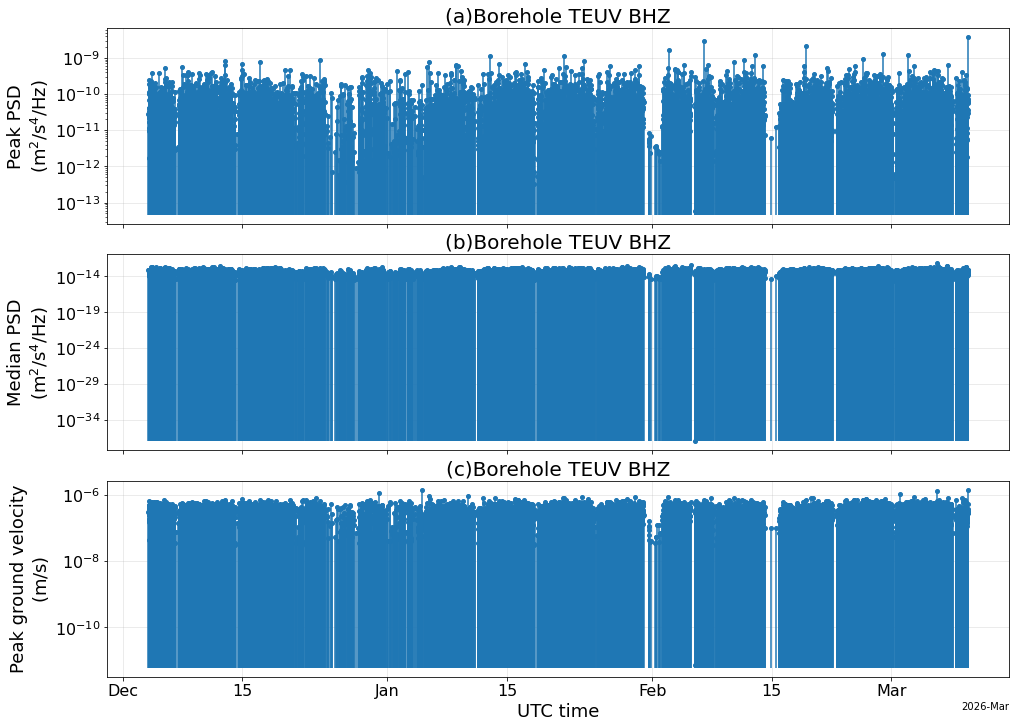

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
from modules import trainStatsMod

stnName = 'TEUV'
compName = 'BHZ'
fName = '/data/gravwav/koley/PSDHistBoreholes/TEUVTrain/train_stats_multi_chunk.pkl'

#open the trainnstats file and plot the PSD and attenuation
with open(fName, 'rb') as f:
        trainStats = pickle.load(f)
trainStatsMod.plotTrainNoTrainPSD(trainStats, title_prefix=stnName + ' '+ compName)
trainStatsMod.plotTrainNoTrainAttenuation(trainStats, title_prefix=stnName + ' '+ compName)        

trainStatsMod.plot_trainstats_event_attributes(
    fName,
    y_keys=("bh_peak_psd", "bh_band_median_psd", "bh_pgv"),
    y_labels = ("Peak PSD\n" + r"($\mathrm{m}^2/\mathrm{s}^4/\mathrm{Hz}$)",
                "Median PSD\n" + r"($\mathrm{m}^2/\mathrm{s}^4/\mathrm{Hz}$)",
                "Peak ground velocity\n" + r"($\mathrm{m}/\mathrm{s}$)",),
    title_prefix='Borehole',
    marker='o',
    linestyle='-',
    ms=5,
    lw=1.5,
    figsize=(14, 10),
    sharex=True,
    sort_by_time=True,
    logy_keys=("bh_peak_psd","bh_band_median_psd","bh_pgv"),
)

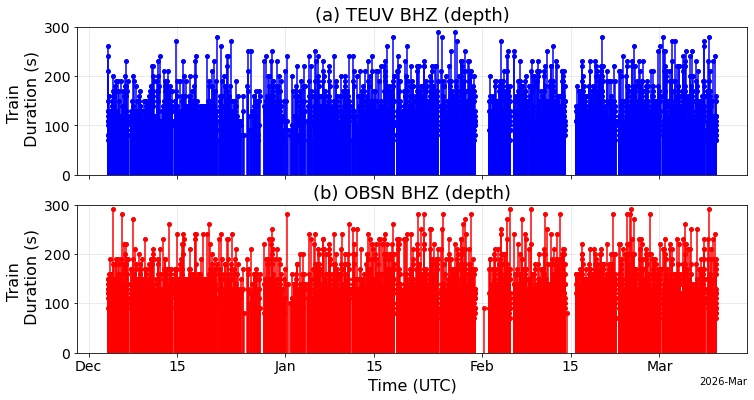

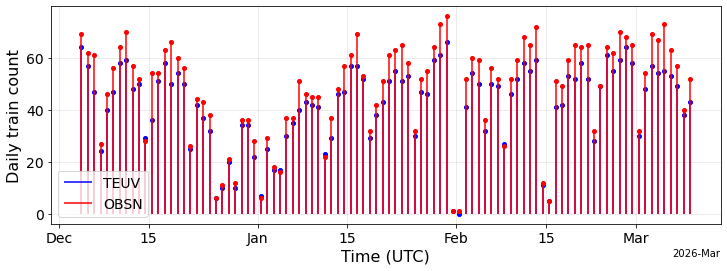

Total Teuv trains = 4020
Total Obsn trains = 4593
% of train time Teuv = 5.769073109567902
% of train time Obsn = 6.761911651234567


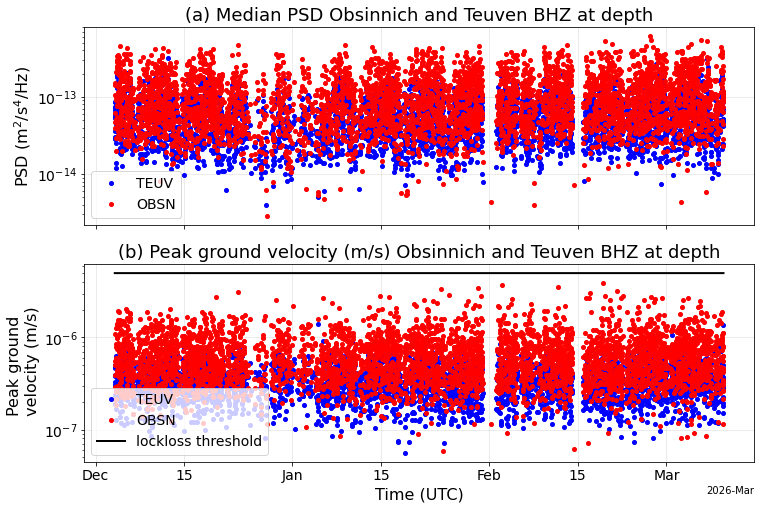

In [4]:
# make more comparitive plots of OBSN and TEUV train statistics

import datetime as dt
from obspy import UTCDateTime

fOBSN = '/data/gravwav/koley/PSDHistBoreholes/OBSNTrain/train_stats_multi_chunk.pkl'
fTEUV = '/data/gravwav/koley/PSDHistBoreholes/TEUVTrain/train_stats_multi_chunk.pkl'
label_fs = 16
title_fs = 18
tick_fs = 14

with open(fOBSN, 'rb') as f:
    trainStatsOBSN = pickle.load(f)

with open(fTEUV, 'rb') as f:
    trainStatsTEUV = pickle.load(f)

eventsOBSN = trainStatsOBSN.get("events", [])
metaOBSN = trainStatsOBSN.get("meta", {})

eventsTEUV = trainStatsTEUV.get("events", [])
metaTEUV = trainStatsTEUV.get("meta", {})

nEventsTEUV = len(eventsTEUV)
nEventsOBSN = len(eventsOBSN)

# tNow is like midday of all dayvector
tStart = min(eventsTEUV[0]['start_utc'], eventsOBSN[0]['start_utc'])
tEnd = max(eventsTEUV[-1]['start_utc'], eventsOBSN[-1]['start_utc'])

day0 = UTCDateTime(tStart.year, tStart.month, tStart.day, 12, 0, 0)
dayN = UTCDateTime(tEnd.year, tEnd.month, tEnd.day, 12, 0, 0)

tVec = []
tNow = day0
while tNow <= dayN:
    tVec.append(tNow)
    tNow += 86400

obsnStruct = {"startTrain":[], "durTrain":[], "tC":[0]*len(tVec), "medianPSD":[], "peakPSD":[], "pgv":[]}
teuvStruct = {"startTrain":[], "durTrain":[], "tC":[0]*len(tVec), "medianPSD":[], "peakPSD":[], "pgv":[]}

dateStart = eventsTEUV[0]['start_utc']
startDay = dateStart.julday

for i in range(0, nEventsTEUV):
    if(eventsTEUV[i]['duration_sec'] > 60 and eventsTEUV[i]['duration_sec'] < 300):
        teuvStruct["startTrain"].append(eventsTEUV[i]['start_utc'])
        teuvStruct["durTrain"].append(eventsTEUV[i]['duration_sec'])
        teuvStruct["medianPSD"].append(eventsTEUV[i]['bh_band_median_psd'])
        teuvStruct["peakPSD"].append(eventsTEUV[i]['bh_peak_psd'])
        teuvStruct["pgv"].append(eventsTEUV[i]['bh_pgv'])

        currDate = eventsTEUV[i]['start_utc']
        dayMid = UTCDateTime(currDate.year, currDate.month, currDate.day, 12, 0, 0)
        dayInd = int((dayMid - day0) / 86400)

        if 0 <= dayInd < len(teuvStruct["tC"]):
            teuvStruct["tC"][dayInd] += 1


dateStart = eventsOBSN[0]['start_utc']
startDay = dateStart.julday
for i in range(0, nEventsOBSN):
    if(eventsOBSN[i]['duration_sec'] > 60 and eventsOBSN[i]['duration_sec'] < 300):
        obsnStruct["startTrain"].append(eventsOBSN[i]['start_utc'])
        obsnStruct["durTrain"].append(eventsOBSN[i]['duration_sec'])
        obsnStruct["medianPSD"].append(eventsOBSN[i]['bh_band_median_psd'])
        obsnStruct["peakPSD"].append(eventsOBSN[i]['bh_peak_psd'])
        obsnStruct["pgv"].append(eventsOBSN[i]['bh_pgv'])

        currDate = eventsOBSN[i]['start_utc']
        dayMid = UTCDateTime(currDate.year, currDate.month, currDate.day, 12, 0, 0)
        dayInd = int((dayMid - day0) / 86400)

        if 0 <= dayInd < len(obsnStruct["tC"]):
            obsnStruct["tC"][dayInd] += 1
            
teuvTPlot = [t.datetime for t in teuvStruct["startTrain"]]
obsnTPlot = [t.datetime for t in obsnStruct["startTrain"]]
                   
locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)

fig, ax = plt.subplots(2,1,figsize=(12,6),sharex=True)

ax[0].vlines(teuvTPlot,0,teuvStruct["durTrain"],'b')
ax[0].plot(teuvTPlot, teuvStruct["durTrain"], 'bo', ms=4)
ax[0].xaxis.set_major_locator(locator)
ax[0].xaxis.set_major_formatter(formatter)
ax[0].set_ylabel("Train \n Duration (s)",fontsize=label_fs)
ax[0].set_title("(a) TEUV BHZ (depth)", fontsize=title_fs)
ax[0].tick_params(axis='both', labelsize=tick_fs)
#ax[0].set_ylim(0,60)
ax[0].grid(True, alpha=0.3)
ax[0].set_ylim(0,300)

ax[1].vlines(obsnTPlot,0,obsnStruct["durTrain"],'r')
ax[1].plot(obsnTPlot, obsnStruct["durTrain"], 'ro', ms=4)
ax[1].xaxis.set_major_locator(locator)
ax[1].xaxis.set_major_formatter(formatter)
ax[1].set_ylabel("Train \n Duration (s)",fontsize=label_fs)
ax[1].set_xlabel("Time (UTC)", fontsize = label_fs)
ax[1].set_title("(b) OBSN BHZ (depth)", fontsize=title_fs)
ax[1].tick_params(axis='both', labelsize=tick_fs)
#ax[1].set_ylim(0,60)
ax[1].grid(True, alpha=0.3)

#ax[1].set_xlim(
#    dt.datetime(2026, 2, 14, 0, 0, 0),
#    dt.datetime(2026, 2, 17, 23, 59, 59)
#)
ax[1].set_ylim(0,300)

######################################################################################################
# plot the daily train count
teuvDailyT = [t.datetime for t in tVec]
obsnDailyT = [t.datetime for t in tVec]
plt.figure(figsize=(12,4))
plt.vlines(teuvDailyT, 0,teuvStruct["tC"],'b', label="TEUV")
plt.plot(teuvDailyT, teuvStruct["tC"], 'bo', ms=4)
plt.vlines(obsnDailyT, 0,obsnStruct["tC"],'r',label="OBSN")
plt.plot(obsnDailyT, obsnStruct["tC"], 'ro', ms=4)
ax = plt.gca()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(formatter)

plt.xlabel("Time (UTC)", fontsize=label_fs)
plt.ylabel("Daily train count", fontsize=label_fs)
plt.tick_params(axis='both', labelsize=tick_fs)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=14)
plt.show()

######################################################################################################
# plot the median PSD and the peak ground velocity
fig2, ax2 = plt.subplots(2,1,figsize=(12,8), sharex=True)
ax2[0].semilogy(teuvTPlot, teuvStruct["medianPSD"], 'bo', ms=4,label='TEUV')
ax2[0].semilogy(obsnTPlot, obsnStruct["medianPSD"], 'ro', ms=4,label='OBSN')
ax2[0].xaxis.set_major_locator(locator)
ax2[0].xaxis.set_major_formatter(formatter)
ax2[0].set_ylabel("PSD ($\mathrm{m}^2/\mathrm{s}^4/\mathrm{Hz}$)",fontsize=label_fs)
ax2[0].set_title("(a) Median PSD Obsinnich and Teuven BHZ at depth", fontsize=title_fs)
ax2[0].tick_params(axis='both', labelsize=tick_fs)
#ax[0].set_ylim(0,60)
ax2[0].grid(True, alpha=0.3)
ax2[0].legend(fontsize=14)

ax2[1].semilogy(teuvTPlot, teuvStruct["pgv"], 'bo', ms=4, label='TEUV')
ax2[1].semilogy(obsnTPlot, obsnStruct["pgv"], 'ro', ms=4, label='OBSN')
ax2[1].plot(teuvTPlot, 5*10**-6*np.ones((len(teuvTPlot),)),'k',lw=2,label='lockloss threshold')
ax2[1].xaxis.set_major_locator(locator)
ax2[1].xaxis.set_major_formatter(formatter)
ax2[1].set_ylabel("Peak ground \n velocity (m/s)",fontsize=label_fs)
ax2[1].set_xlabel("Time (UTC)", fontsize = label_fs)
ax2[1].set_title("(b) Peak ground velocity (m/s) Obsinnich and Teuven BHZ at depth", fontsize=title_fs)
ax2[1].tick_params(axis='both', labelsize=tick_fs)
#ax[1].set_ylim(0,60)
ax2[1].grid(True, alpha=0.3)
ax2[1].legend(fontsize=14)

totTeuvTrains = np.sum(teuvStruct["tC"])
totObsnTrains = np.sum(obsnStruct["tC"])

print('Total Teuv trains = ' + str(totTeuvTrains))
print('Total Obsn trains = ' + str(totObsnTrains))

obsnTrainPrct = np.sum(obsnStruct["durTrain"])/(96*86400)*100
teuvTrainPrct = np.sum(teuvStruct["durTrain"])/(96*86400)*100

print('% of train time Teuv = ' + str(teuvTrainPrct))
print('% of train time Obsn = ' + str(obsnTrainPrct))
